In [1]:
import sys
sys.path.insert(0, '/home/shivamsingh/documents/566FinalProject')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler

from helper import MODEL_NAMES
from evaluation import evaluate_dataset
from plotting import COLOR_MAP, format_standard_axes

In [2]:
RANDOM_SEED  = 42
N_SAMPLES    = 1500
NOISE_LEVELS = [0.0, 0.1, 0.5, 1.0]

raw_data  = {}
results   = {}
baselines = {}

for noise in NOISE_LEVELS:
    X_raw, t = make_swiss_roll(n_samples=N_SAMPLES, noise=noise, random_state=RANDOM_SEED)
    X = StandardScaler().fit_transform(X_raw).astype(np.float32)
    y = np.floor((t - t.min()) / (t.max() - t.min()) * 8).clip(0, 7).astype(np.int64)
    raw_data[noise] = (X_raw, t)
    baseline, dim_data = evaluate_dataset(f"noise={noise}", X, y, num_runs=3, dimensions=[2])
    results[noise]   = dim_data[2]
    baselines[noise] = baseline
    print(f"noise={noise} done")

noise=0.0 done
noise=0.1 done
noise=0.5 done
noise=1.0 done


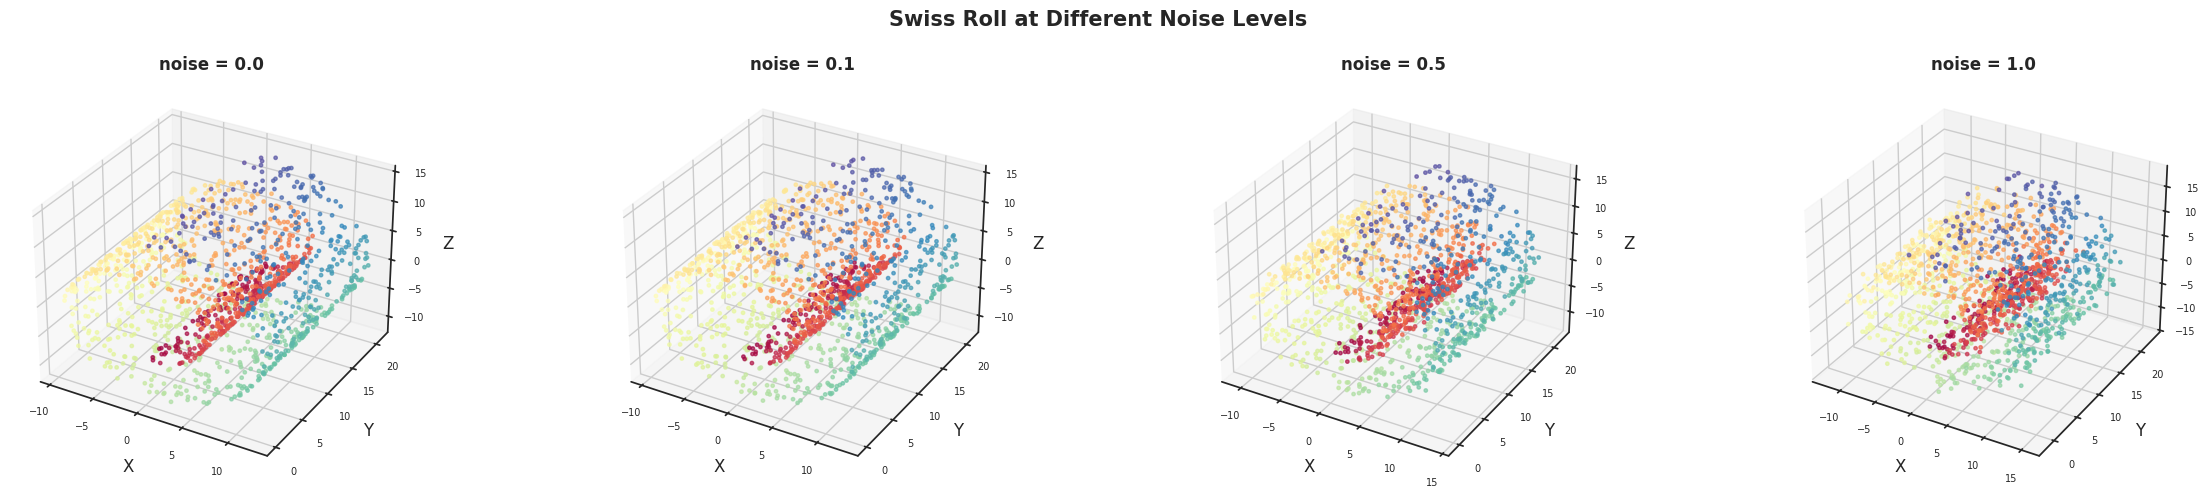

In [3]:
fig, axes = plt.subplots(1, len(NOISE_LEVELS), figsize=(6 * len(NOISE_LEVELS), 5),
                         subplot_kw={'projection': '3d'})

for ax, noise in zip(axes, NOISE_LEVELS):
    X_raw, t = raw_data[noise]
    ax.scatter(X_raw[:, 0], X_raw[:, 1], X_raw[:, 2], c=t, cmap='Spectral', s=6, alpha=0.7)
    ax.set_title(f'noise = {noise}', fontsize=12, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.tick_params(labelsize=7)

fig.suptitle('Swiss Roll at Different Noise Levels', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/swiss_roll_noise_3d.png', dpi=300)
plt.show()

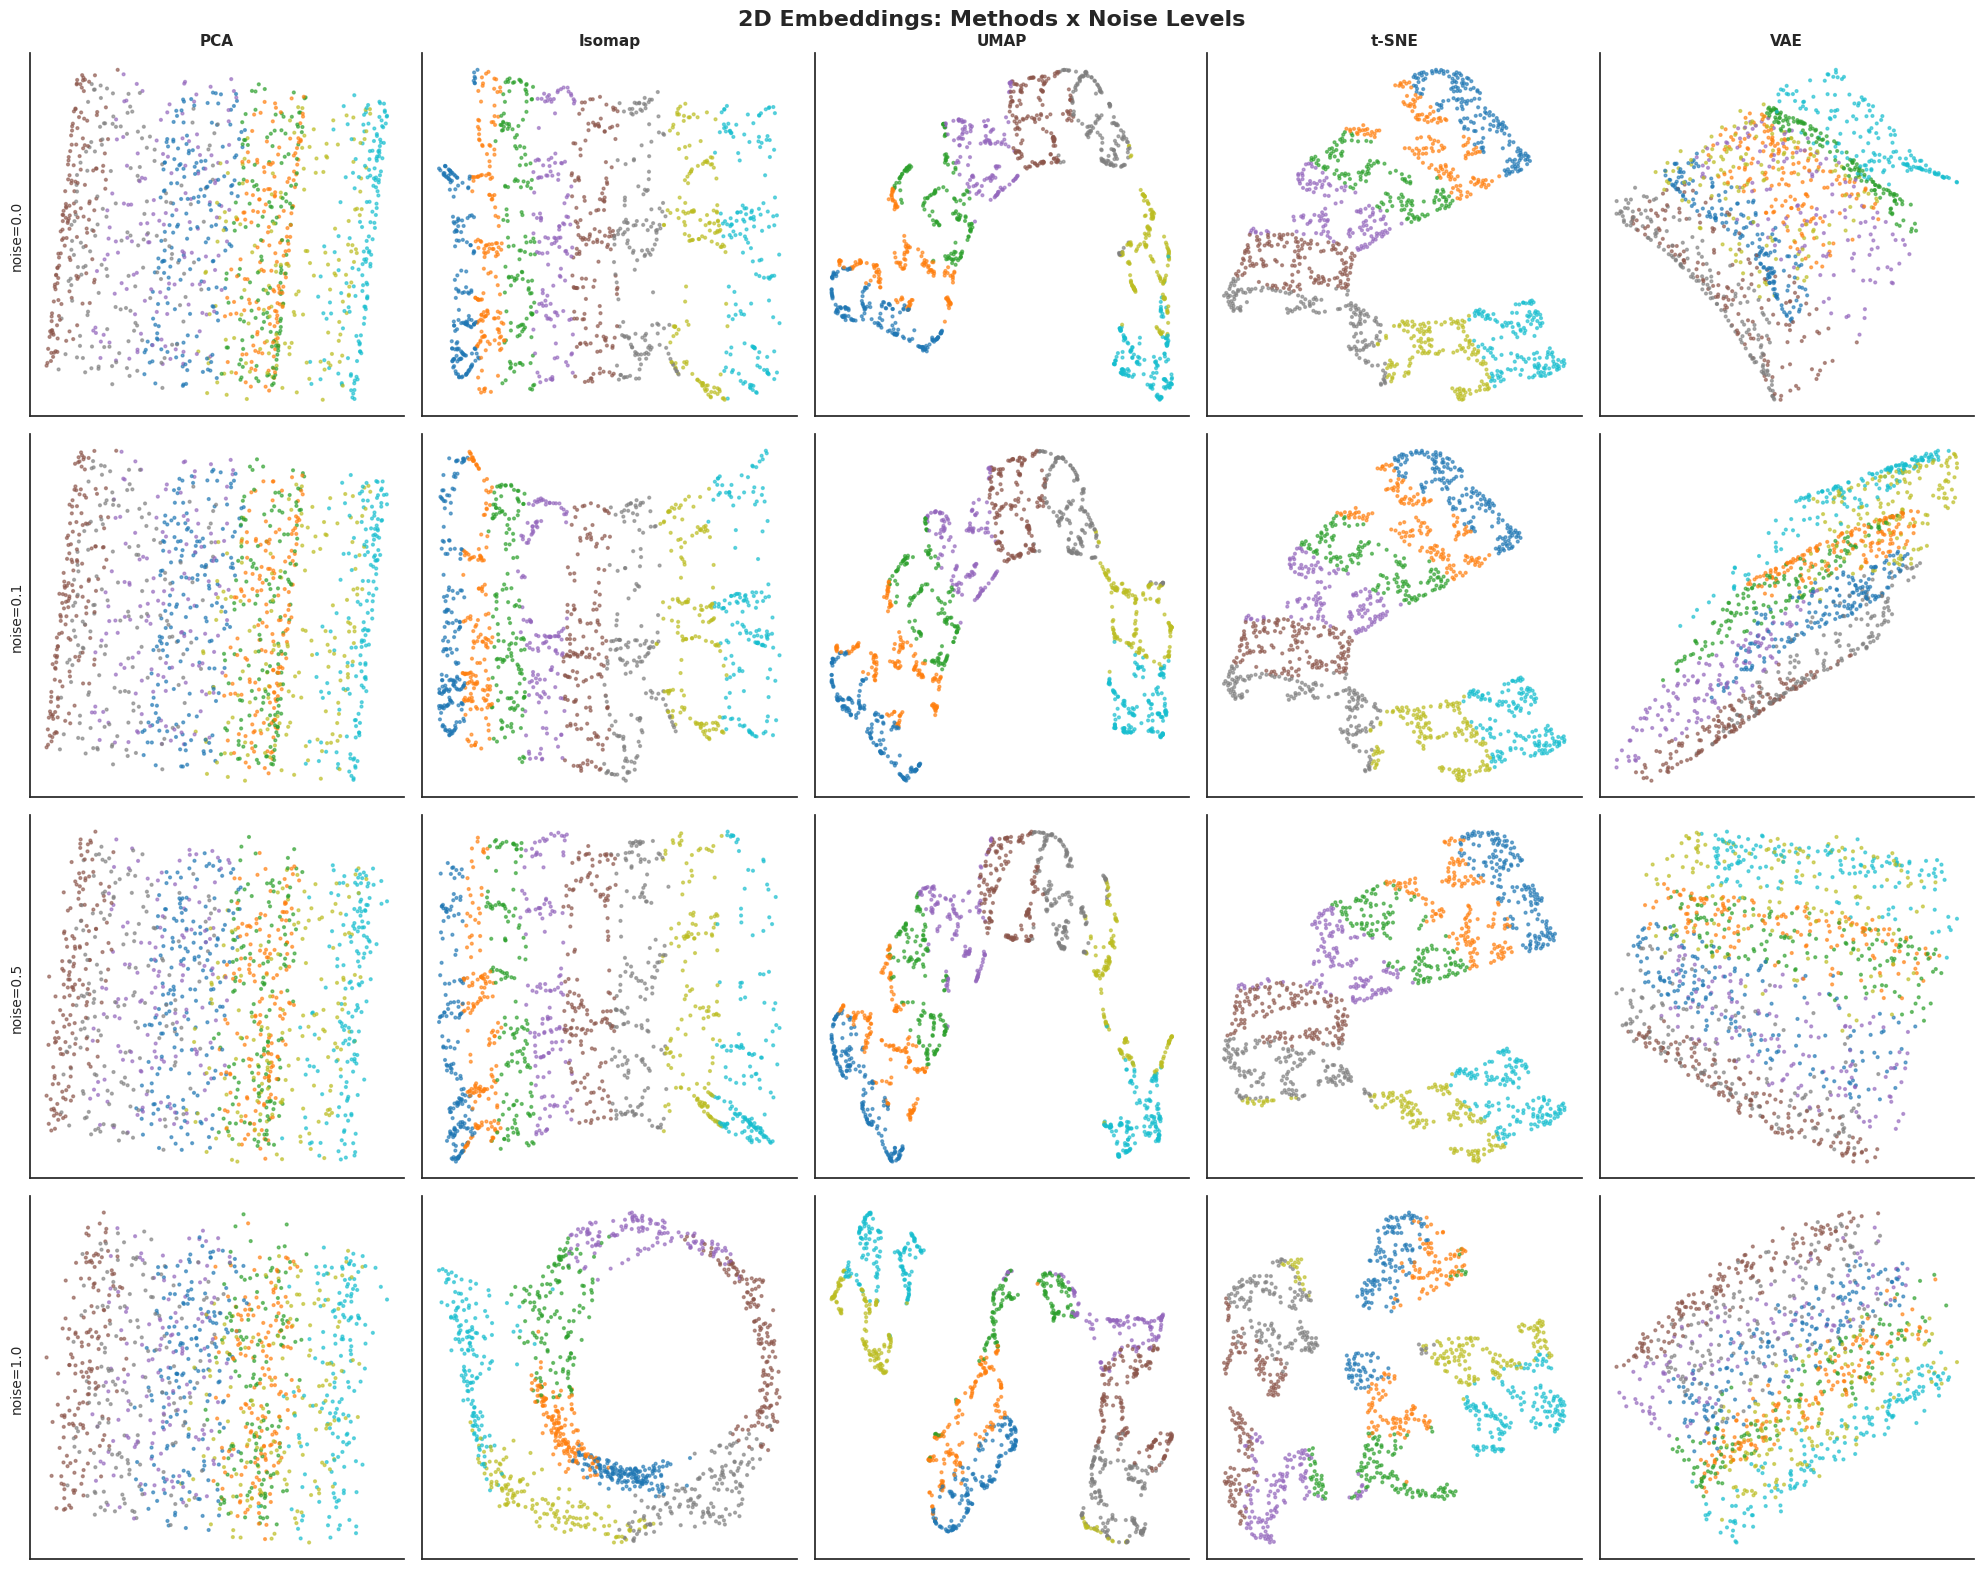

In [4]:
n_noise  = len(NOISE_LEVELS)
n_models = len(MODEL_NAMES)

fig, axes = plt.subplots(n_noise, n_models, figsize=(4 * n_models, 4 * n_noise))
fig.suptitle('2D Embeddings: Methods x Noise Levels', fontsize=16, fontweight='bold')

for i, noise in enumerate(NOISE_LEVELS):
    for j, model_name in enumerate(MODEL_NAMES):
        ax = axes[i, j]
        if model_name not in results[noise]:
            ax.set_visible(False)
            continue
        data   = results[noise][model_name]
        X_2d   = data['X_train_reduced']
        labels = data['y_train']
        ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', alpha=0.6, s=4)
        if i == 0:
            ax.set_title(model_name, fontsize=11, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'noise={noise}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/swiss_roll_embeddings_grid.png', dpi=300)
plt.show()

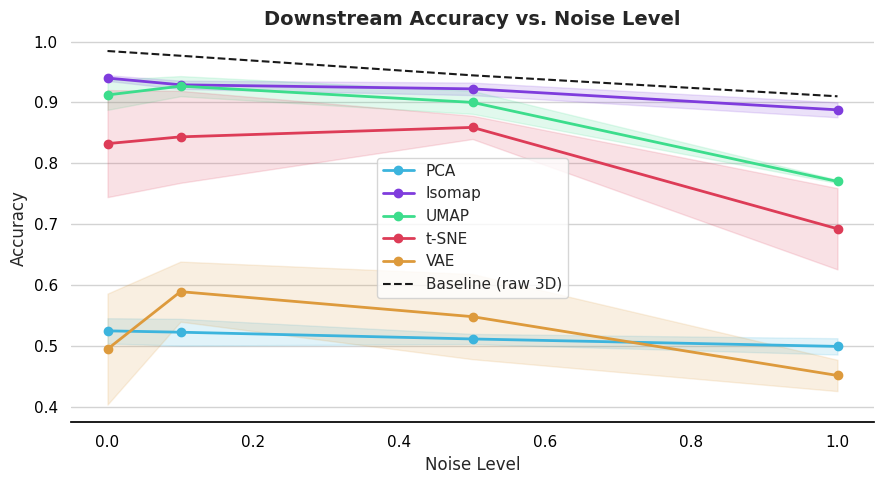

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

for model_name in MODEL_NAMES:
    accs = []
    errs = []
    for noise in NOISE_LEVELS:
        if model_name in results[noise]:
            accs.append(results[noise][model_name]['acc_mean'])
            errs.append(results[noise][model_name]['acc_std'])
        else:
            accs.append(np.nan)
            errs.append(0.0)
    color = COLOR_MAP[model_name]['dark']
    ax.plot(NOISE_LEVELS, accs, marker='o', label=model_name, color=color, linewidth=2, markersize=6)
    ax.fill_between(NOISE_LEVELS,
                    [a - e for a, e in zip(accs, errs)],
                    [a + e for a, e in zip(accs, errs)],
                    alpha=0.15, color=color)

baseline_accs = [baselines[n]['acc_mean'] for n in NOISE_LEVELS]
ax.plot(NOISE_LEVELS, baseline_accs, 'k--', linewidth=1.5, label='Baseline (raw 3D)')

ax.set_xlabel('Noise Level', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Downstream Accuracy vs. Noise Level', fontsize=14, fontweight='bold')
ax.legend(frameon=True)
format_standard_axes(ax)
plt.tight_layout()
plt.savefig('figures/accuracy_vs_noise.png', dpi=300)
plt.show()

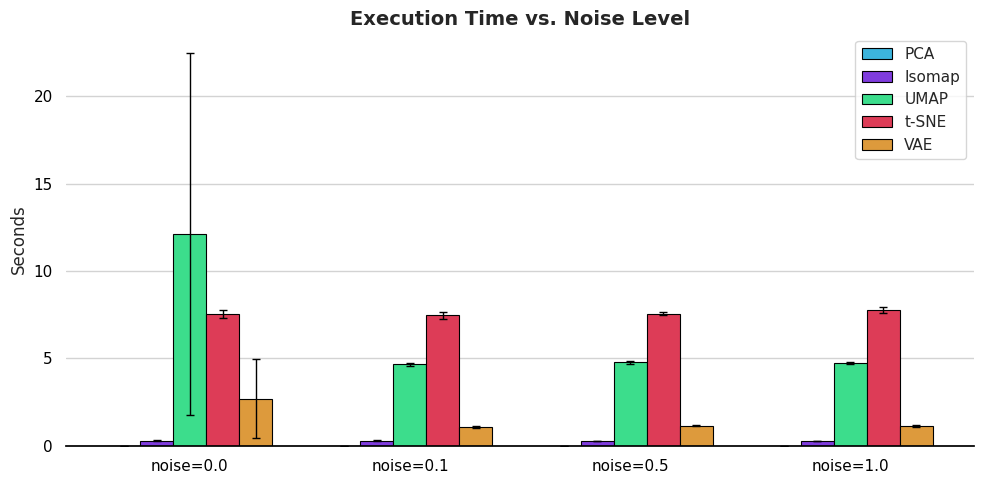

In [6]:
n_models  = len(MODEL_NAMES)
bar_width = 0.15
x         = np.arange(len(NOISE_LEVELS))

fig, ax = plt.subplots(figsize=(10, 5))

for i, model_name in enumerate(MODEL_NAMES):
    times = [results[n][model_name]['time_mean'] if model_name in results[n] else 0 for n in NOISE_LEVELS]
    errs  = [results[n][model_name]['time_std']  if model_name in results[n] else 0 for n in NOISE_LEVELS]
    color  = COLOR_MAP[model_name]['dark']
    offset = (i - n_models / 2 + 0.5) * bar_width
    ax.bar(x + offset, times, width=bar_width, color=color, label=model_name,
           edgecolor='black', linewidth=0.8)
    ax.errorbar(x + offset, times, yerr=errs, fmt='none', c='black', capsize=3, elinewidth=1)

ax.set_xticks(x)
ax.set_xticklabels([f'noise={n}' for n in NOISE_LEVELS])
ax.set_ylabel('Seconds', fontsize=12)
ax.set_title('Execution Time vs. Noise Level', fontsize=14, fontweight='bold')
ax.legend(frameon=True)
format_standard_axes(ax)
plt.tight_layout()
plt.savefig('figures/time_vs_noise.png', dpi=300)
plt.show()